## Comparison of ESA CCI Snow LAC and GAC data
#### Using values processed with lac_gac.py
#### Author: Elias Frey, RSGB/Unibe, 25.06.2024

### Import statements

In [20]:
import os
import warnings
import csv
import glob
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

### Functions

In [21]:
def get_coords():
    """
    Get region name and coordinate
    """
    coords_dict = {
        'usa_Alaska': [66.16, -153.37],                # Gates of the Arctic National Park, forest
        'can_Auyuittuq': [67.5, -65],                 # Auyuittuq National Park, mountains
        'chl_Rafael': [-46.76, -73,55],           # Parque Nacional Laguna San Rafael, glacier
        'nor_Jotunheim': [61.68, 7.03],           # Glacier
        'rus_Karelia': [61.82, 33.24],           # agriculture, forest
        'rus_Siberia': [63.32, 115.21],         # forest
    }

    return coords_dict

In [22]:
def get_csv_path(csv_main_dir, region):
    """
    Get csv file from directory
    """
    csv_file = glob.glob(os.path.join(path_to_csv_files, f"{region}*.csv"))[0]
    return csv_file

In [23]:
def get_csv_file(filename):
    """
    Get path of csv file for single plotting
    """
    csv_path = f'csv/{filename.split("_")[3]}_{filename.split("_")[4]}/{filename}.csv'
    return csv_path

In [24]:
def read_csv(csv_path):
    """
    Read csv file
    """
    # Initialize empty dictionary to store data
    csv_dict = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list))))
    
    # Read data from CSV file and populate dictionary
    with open(csv_path, 'r', newline='') as csv_file:
        reader = csv.DictReader(csv_file)
        for row in reader:
            date_str = row['date']
            platform = row['datatype']
            satellite = row['satellite']
            region = row['region']
            data_str = row['data']
            
            # Convert date string to datetime object
            date = datetime.strptime(date_str, '%Y%m%d').strftime('%d-%m-%Y')
            
            # Convert data string to list of floats, handling NaN values
            data = [np.nan if val == 'nan' else float(val) for val in data_str.strip('[]').split(',')]
            
            # Update dictionary
            csv_dict[date][platform][satellite][region] = data

    return csv_dict

In [25]:
def filter_dates(data, start_date, end_date, date_format="%d-%m-%Y"):
    """
    Filters the data dictionary to include only entries within the specified date range
    """
    start = datetime.strptime(start_date, date_format)
    end = datetime.strptime(end_date, date_format)

    filtered_data = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list))))

    for date_str, value in data.items():
        date = datetime.strptime(date_str, date_format)
        if start <= date <= end:
            filtered_data[date_str] = value

    return filtered_data

In [26]:
def get_regionstring(csv_path):
    country, region = os.path.basename(csv_path).split('_')[0:2]
    plot_title = f"{region.capitalize()} ({country.upper()})"
    return plot_title

In [27]:
def plot_comparison(var_dict, csv_path, plot_category, date_range):
    """
    Plot comparison of LAC and GAC with specified parameters
    """
    # Ignore NaN values warning
    warnings.filterwarnings("ignore", category=RuntimeWarning, message="All-NaN axis encountered")

    # Create empty arrays
    x = list(var_dict.keys())
    lac_noaa11_y = [np.nan] * len(x)
    gac_noaa11_y = [np.nan] * len(x)
    lac_noaa14_y = [np.nan] * len(x)
    gac_noaa14_y = [np.nan] * len(x)
    
    for i, (date, data) in enumerate(var_dict.items()):
        for platform, platform_data in data.items():
            for satellite, satellite_data in platform_data.items():
                for region, region_data in satellite_data.items():  # Iterate over regions
                    if region_data:  # Check if region data is not empty
                        max_value = np.nanmax(region_data)
                        if not np.isnan(max_value):
                            category = int(max_value / 10) * 10  # Convert max_value to category
                            if platform == 'lac' and satellite == 'noaa11':
                                if plot_category:
                                    lac_noaa11_y[i] = category
                                else:
                                    lac_noaa11_y[i] = max_value
                            elif platform == 'gac' and satellite == 'noaa11':
                                if plot_category:
                                    gac_noaa11_y[i] = category
                                else:
                                    gac_noaa11_y[i] = max_value
                            elif platform == 'lac' and satellite == 'noaa14':
                                if plot_category:
                                    lac_noaa14_y[i] = category
                                else:
                                    lac_noaa14_y[i] = max_value
                            elif platform == 'gac' and satellite == 'noaa14':
                                if plot_category:
                                    gac_noaa14_y[i] = category
                                else:
                                    gac_noaa14_y[i] = max_value
    
    

    plt.figure(figsize=(10, 6))    
    
    # Plot lines only for satellite category containig data
    if not all(i != i for i in lac_noaa11_y):
        plt.plot(x, lac_noaa11_y, label='LAC NOAA11', marker='o', linestyle='', color='#38b000')
    if not all(i != i for i in lac_noaa14_y):
        plt.plot(x, lac_noaa14_y, label='LAC NOAA14', marker='o', linestyle='', color='#31572c')
    if not all(i != i for i in gac_noaa11_y):
        plt.plot(x, gac_noaa11_y, label='GAC NOAA11', marker='o', linestyle='', color='#ffdd00')
    if not all(i != i for i in gac_noaa14_y):
        plt.plot(x, gac_noaa14_y, label='GAC NOAA14', marker='o', linestyle='', color='#ffb703')
    
    # Set plot labels and title
    plt.xlabel('')
    plt.ylabel('Snow Cover Fraction [%]')
    csv_name = get_regionstring(csv_path)
    if plot_category:
        plt.title(f'Comparison of LAC & GAC SCFG (10-stage) {csv_name} SCFG 0.15° × 0.15°')
    else:
        plt.title(f'Comparison of LAC & GAC SCFG {csv_name} SCFG 0.15° × 0.15°')
    
    # Add legend
    plt.legend()
    plt.xticks(np.arange(0, len(x), step=max(len(x)//10, 1)), rotation=45)
    plt.tight_layout()  
    plt.grid(False)  
    plt.savefig(f'plots/{date_range}/{csv_name}_SCFG_comparison_2x2_degree_{date_range}.png')
    plt.show()

In [28]:
def plot_difference(var_dict, csv_path, date_range):
    """
    Plot differences of LAC and GAC with specified parameters
    """
    # Ignore NaN values warning
    warnings.filterwarnings("ignore", category=RuntimeWarning, message="All-NaN axis encountered")

    # Create empty arrays
    x = list(var_dict.keys())
    lac_noaa11_y = [np.nan] * len(x)
    gac_noaa11_y = [np.nan] * len(x)
    lac_noaa14_y = [np.nan] * len(x)
    gac_noaa14_y = [np.nan] * len(x)
    
    for i, (date, data) in enumerate(var_dict.items()):
        for platform, platform_data in data.items():
            for satellite, satellite_data in platform_data.items():
                for region, region_data in satellite_data.items():  # Iterate over regions
                    if region_data:  # Check if region data is not empty
                        max_value = np.nanmax(region_data)
                        if not np.isnan(max_value):
                            category = int(max_value / 10) * 10  # Convert max_value to category
                            if platform == 'lac' and satellite == 'noaa11':
                                lac_noaa11_y[i] = category
                            elif platform == 'gac' and satellite == 'noaa11':
                                gac_noaa11_y[i] = category
                            elif platform == 'lac' and satellite == 'noaa14':
                                lac_noaa14_y[i] = category
                            elif platform == 'gac' and satellite == 'noaa14':
                                gac_noaa14_y[i] = category
    
    
    # Create arrays from lists
    arr1 = np.array(lac_noaa11_y)
    arr2 = np.array(gac_noaa11_y)
    arr3= np.array(lac_noaa14_y)
    arr4 = np.array(gac_noaa14_y)
    
    # Calculate differences, ignoring NaN values
    differences1 = np.where(np.isnan(arr1) | np.isnan(arr2), np.nan, arr1 - arr2)
    differences2 = np.where(np.isnan(arr3) | np.isnan(arr4), np.nan, arr3 - arr4)

    # Find valid (non-NaN) differences
    valid1 = ~np.isnan(differences1)
    valid2 = ~np.isnan(differences2)

    top10_diff1 = sorted(
    zip(np.array(x)[valid1], differences1[valid1]),
    key=lambda t: abs(t[1]),
    reverse=True
    )[:10]
    
    top10_diff2 = sorted(
        zip(np.array(x)[valid2], differences2[valid2]),
        key=lambda t: abs(t[1]),
        reverse=True
    )[:10]
    
    # Plot data
    plt.figure(figsize=(10, 6))
    
    plt.plot(x, differences1, label='LAC-GAC NOAA11', marker='.', linestyle='', color='#0077b6')
    plt.plot(x, differences2, label='LAC-GAC NOAA14', marker='.', linestyle='', color='#023e8a')
    
    # Set plot labels and title
    plt.xlabel('')
    plt.ylabel('Differences in Snow Cover Fraction [%]')
    csv_name = get_regionstring(csv_path)
    plt.title(f'Differences of LAC - GAC SCFG (10-step) {csv_name} SCFG 0.15° × 0.15°')
    
    # Add legend
    plt.legend()
    plt.xticks(np.arange(0, len(x), step=max(len(x)//10, 1)), rotation=45)
    plt.tight_layout()
    plt.grid(False)
    
    plt.savefig(f'plots/{date_range}/{csv_name}_SCFG_difference_2x2_degree_{date_range}.png')
    plt.show()

    # Print the 10 largest differences
    print(f"\nTop 10 NOAA11 LAC-GAC differences for {csv_name}:")
    for date, diff in top10_diff1:
        print(f"{date}: {diff}")
    
    print(f"\nTop 10 NOAA14 LAC-GAC differences for {csv_name}:")
    for date, diff in top10_diff2:
        print(f"{date}: {diff}")

    return top10_diff1, top10_diff2

### User input

In [29]:
### DEFINE PLOT PARAMETERS ###

# Csv file name
path_to_csv_files = 'csv/SCFG015x015_degree/'

# Range of Plot date
start_date = '01-01-1992'
end_date = '31-12-1996'

# Comparision plots
plot_category = False               # Categorize SCF values (10-stages)
fullrange_comparison = False        # Ignores start_date and end_date for comparison plots

# Differences plots
fullrange_differences = True        # Ignores start_date and end_date for difference plots

### Plotting

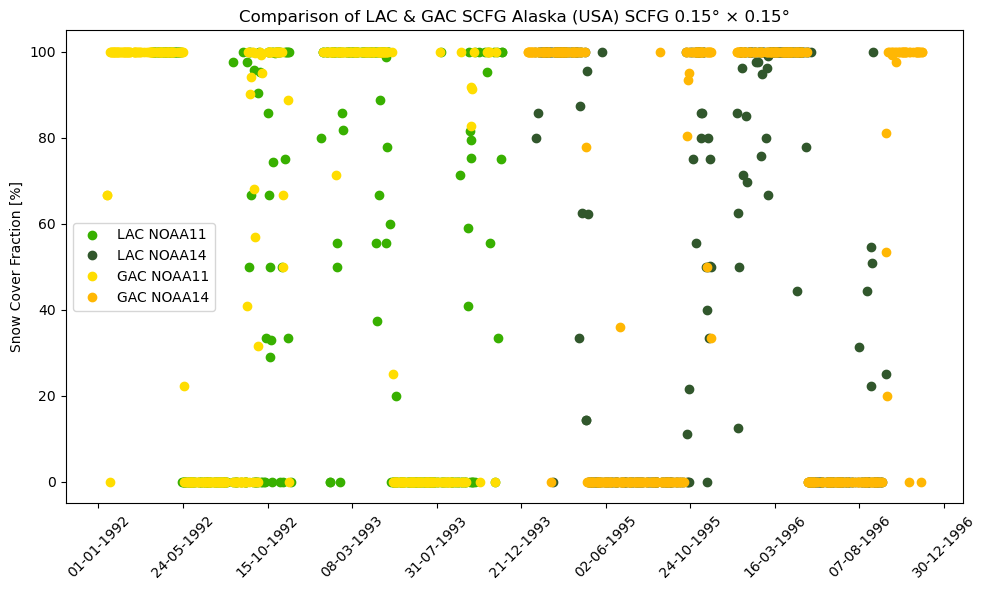

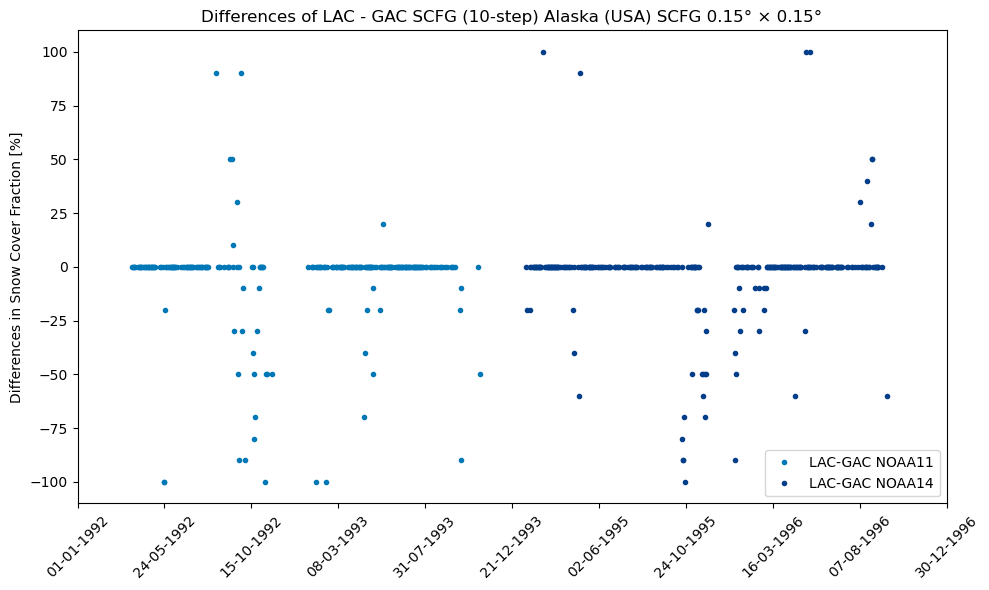


Top 10 NOAA11 LAC-GAC differences for Alaska (USA):
23-05-1992: -100.0
24-05-1992: -100.0
06-11-1992: -100.0
30-01-1993: -100.0
15-02-1993: -100.0
18-08-1992: 90.0
24-09-1992: -90.0
28-09-1992: 90.0
05-10-1992: -90.0
28-09-1993: -90.0

Top 10 NOAA14 LAC-GAC differences for Alaska (USA):
01-03-1995: 100.0
22-10-1995: -100.0
11-05-1996: 100.0
17-05-1996: 100.0
01-05-1995: 90.0
19-10-1995: -90.0
20-10-1995: -90.0
14-01-1996: -90.0
18-10-1995: -80.0
21-10-1995: -70.0


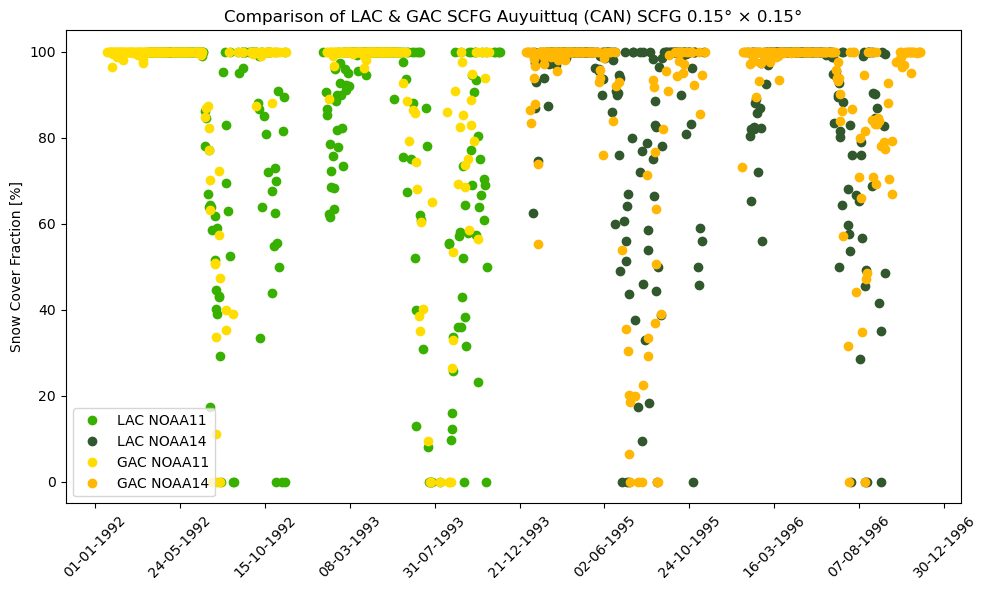

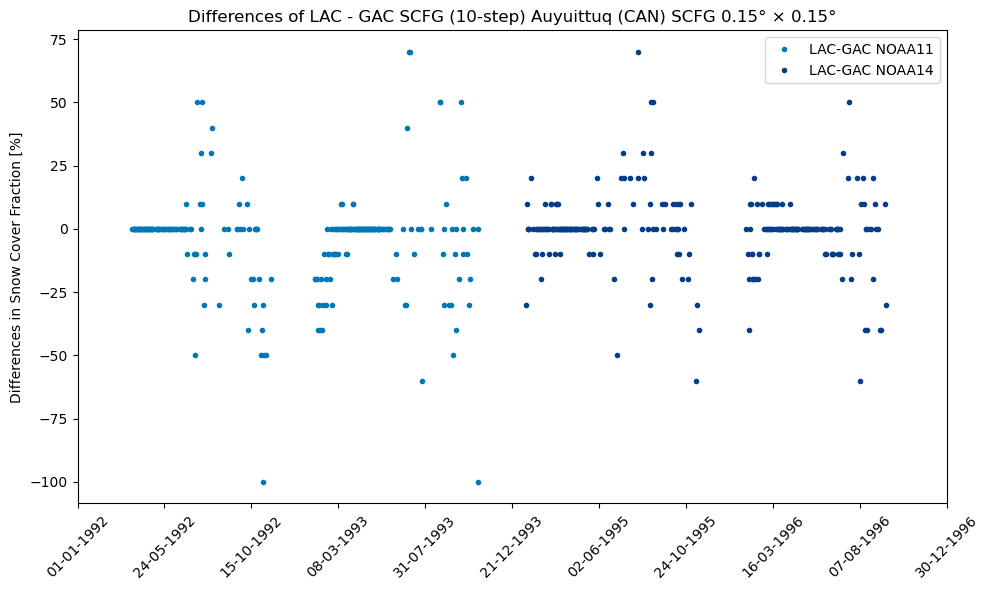


Top 10 NOAA11 LAC-GAC differences for Auyuittuq (CAN):
03-11-1992: -100.0
25-10-1993: -100.0
05-07-1993: 70.0
06-07-1993: 70.0
26-07-1993: -60.0
14-07-1992: -50.0
17-07-1992: 50.0
26-07-1992: 50.0
31-10-1992: -50.0
05-11-1992: -50.0

Top 10 NOAA14 LAC-GAC differences for Auyuittuq (CAN):
05-08-1995: 70.0
10-11-1995: -60.0
08-08-1996: -60.0
02-07-1995: -50.0
27-08-1995: 50.0
31-08-1995: 50.0
21-07-1996: 50.0
15-11-1995: -40.0
06-02-1996: -40.0
16-08-1996: -40.0


IndexError: list index out of range

In [31]:
date_range = start_date.replace('-', '') + '_' + end_date.replace('-', '') # Create string for folder name
# Create dirs
if not os.path.isdir('plots/'):
    os.makedirs('plots/')
if not os.path.isdir(f'plots/{date_range}/'):
    os.makedirs(f'plots/{date_range}/')

for region, coords in get_coords().items():
    csv_path = get_csv_path(path_to_csv_files, region)
    csv_file = read_csv(csv_path)
    filtered_data = filter_dates(csv_file, start_date, end_date)
    # Plot
    if fullrange_comparison:
        plot_comparison(var_dict = csv_file, csv_path = csv_path, plot_category = plot_category, date_range=date_range)
    else:
        plot_comparison(var_dict = filtered_data, csv_path = csv_path, plot_category = plot_category, date_range=date_range)
    
    if fullrange_differences:
        plot_difference(var_dict = csv_file, csv_path = csv_path, date_range = date_range)
    else:
        plot_difference(var_dict = filtered_data, csv_path = csv_path, date_range = date_range)

### Create single plots

In [ ]:
### DEFINE PLOT PARAMETERS ###

# Csv file name
csv_filename = 'rus_Karelia_values_20260817_123456'

# Range of Plot date
start_date = '01-01-1992'
end_date = '31-12-1996'

# Comparision plots
plot_category = False               # Categorize SCF values (10-stages)
fullrange_comparison = False        # ignores start_date and end_date for comparison plots

# Differences plots
fullrange_differences = True        # ignores start_date and end_date for difference plots

In [13]:
# Define the CSV file path
csv_path = get_csv_file(csv_filename)

In [14]:
csv_path2 = 'csv/SCFG015x015_degree/rus_Karelia_values_20260817_123456.csv'

In [15]:
# Read csv file
new_dict = read_csv(csv_path2)

In [16]:
# Filter data by defined time span
filtered_data = filter_dates(new_dict, start_date, end_date)

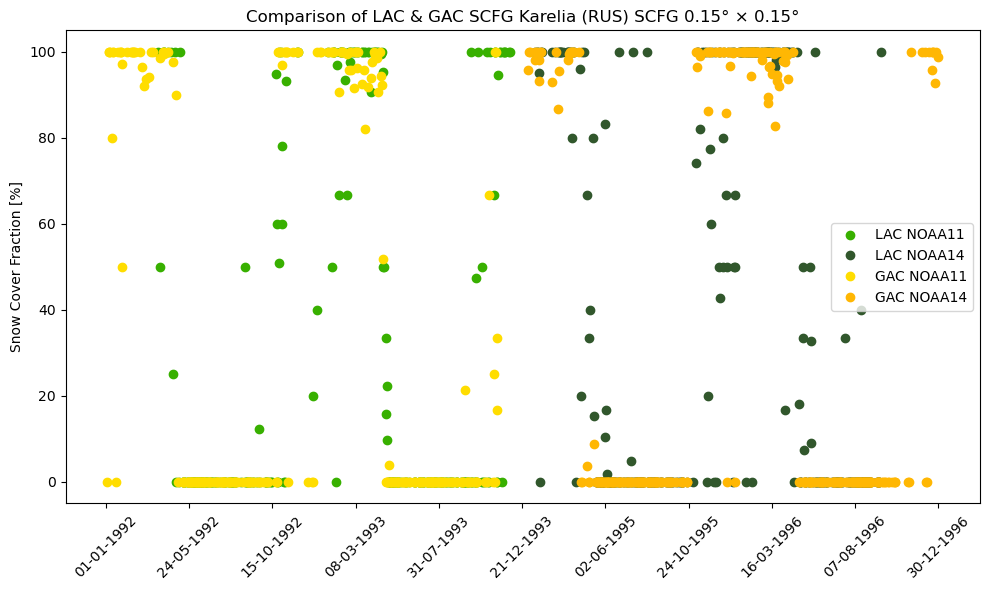

In [17]:
# Plot
if fullrange_comparison:
    plot_comparison(var_dict = new_dict, csv_path = csv_path, plot_category = plot_category, date_range=date_range)
else:
    plot_comparison(var_dict = filtered_data, csv_path = csv_path, plot_category = plot_category, date_range=date_range)

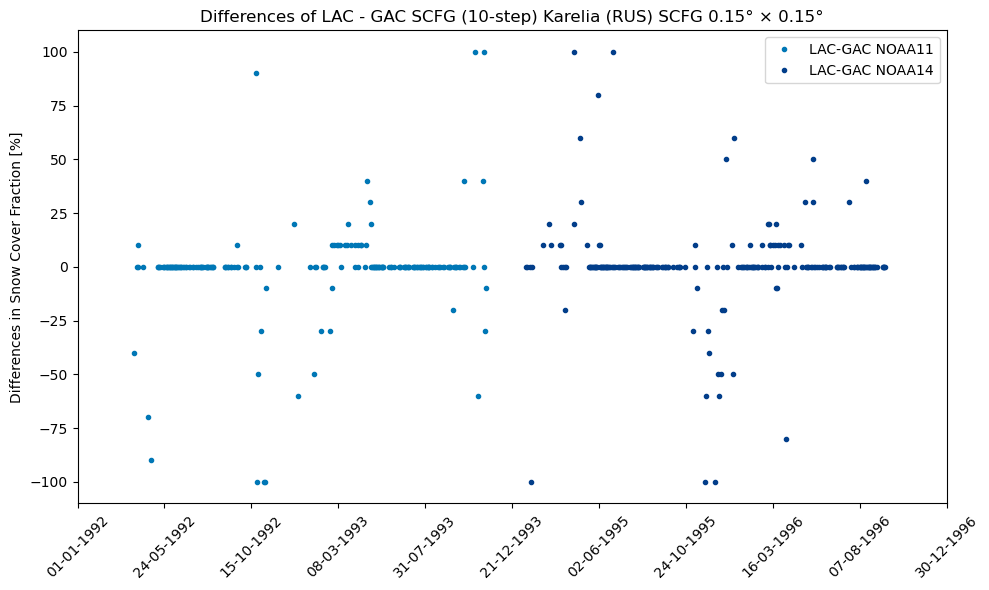


Top 10 NOAA11 LAC-GAC differences for Karelia (RUS):
25-10-1992: -100.0
05-11-1992: -100.0
06-11-1992: -100.0
21-10-1993: 100.0
04-11-1993: 100.0
01-05-1992: -90.0
22-10-1992: 90.0
26-04-1992: -70.0
01-01-1993: -60.0
25-10-1993: -60.0

Top 10 NOAA14 LAC-GAC differences for Karelia (RUS):
09-02-1995: -100.0
22-04-1995: 100.0
25-06-1995: 100.0
24-11-1995: -100.0
11-12-1995: -100.0
01-06-1995: 80.0
07-04-1996: -80.0
02-05-1995: 60.0
26-11-1995: -60.0
18-12-1995: -60.0


In [18]:
# Plot
if fullrange_differences:
    plot_difference(var_dict = new_dict, csv_path = csv_path, date_range=date_range)
else:
    plot_difference(var_dict = filtered_data, csv_path = csv_path, date_range=date_range)

In [36]:
### DEFINE PLOT PARAMETERS ###

# Csv file name
csv_filename = 'rus_Siberia_values_20260817_123456'

# Range of Plot date
start_date = '01-01-1992'
end_date = '31-12-1996'

# Comparision plots
plot_category = False               # Categorize SCF values (10-stages)
fullrange_comparison = False        # ignores start_date and end_date for comparison plots

# Differences plots
fullrange_differences = True        # ignores start_date and end_date for difference plots

In [39]:
# Define the CSV file path
csv_path = get_csv_file(csv_filename)
csv_path2 = 'csv/SCFG015x015_degree/rus_Siberia_values_20260817_123456.csv'
# Read csv file
new_dict = read_csv(csv_path2)
# Filter data by defined time span
filtered_data = filter_dates(new_dict, start_date, end_date)

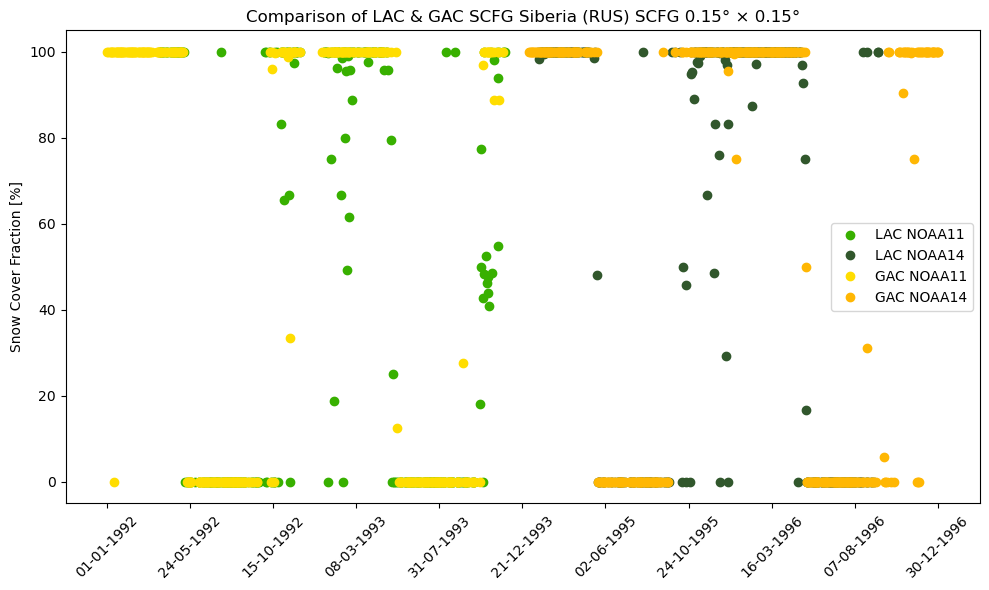

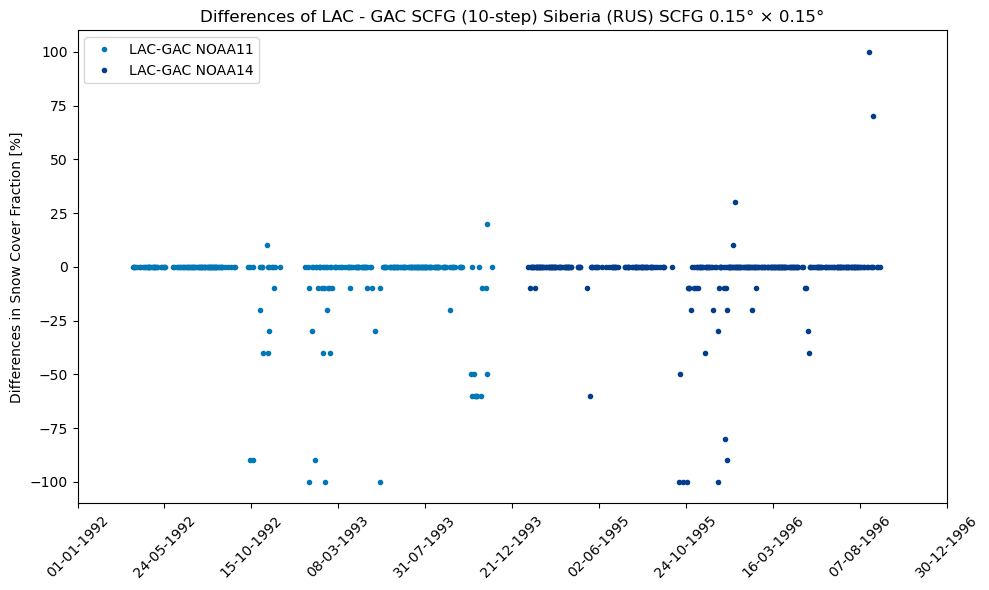


Top 10 NOAA11 LAC-GAC differences for Siberia (RUS):
18-01-1993: -100.0
14-02-1993: -100.0
16-05-1993: -100.0
13-10-1992: -90.0
18-10-1992: -90.0
29-01-1993: -90.0
15-10-1993: -60.0
20-10-1993: -60.0
22-10-1993: -60.0
23-10-1993: -60.0

Top 10 NOAA14 LAC-GAC differences for Siberia (RUS):
13-10-1995: -100.0
19-10-1995: -100.0
26-10-1995: -100.0
17-12-1995: -100.0
22-08-1996: 100.0
31-12-1995: -90.0
28-12-1995: -80.0
29-08-1996: 70.0
18-05-1995: -60.0
15-10-1995: -50.0


In [40]:
# Plot
if fullrange_comparison:
    plot_comparison(var_dict = new_dict, csv_path = csv_path, plot_category = plot_category, date_range=date_range)
else:
    plot_comparison(var_dict = filtered_data, csv_path = csv_path, plot_category = plot_category, date_range=date_range)

    # Plot
if fullrange_differences:
    plot_difference(var_dict = new_dict, csv_path = csv_path, date_range=date_range)
else:
    plot_difference(var_dict = filtered_data, csv_path = csv_path, date_range=date_range)

In [42]:
### DEFINE PLOT PARAMETERS ###

# Csv file name
csv_filename = 'nor_Jotunheim_values_20260817_123456'

# Range of Plot date
start_date = '01-01-1992'
end_date = '31-12-1996'

# Comparision plots
plot_category = False               # Categorize SCF values (10-stages)
fullrange_comparison = False        # ignores start_date and end_date for comparison plots

# Differences plots
fullrange_differences = True        # ignores start_date and end_date for difference plots

In [43]:
# Define the CSV file path
csv_path = get_csv_file(csv_filename)
csv_path2 = 'csv/SCFG015x015_degree/nor_Jotunheim_values_20260817_123456.csv'
# Read csv file
new_dict = read_csv(csv_path2)
# Filter data by defined time span
filtered_data = filter_dates(new_dict, start_date, end_date)

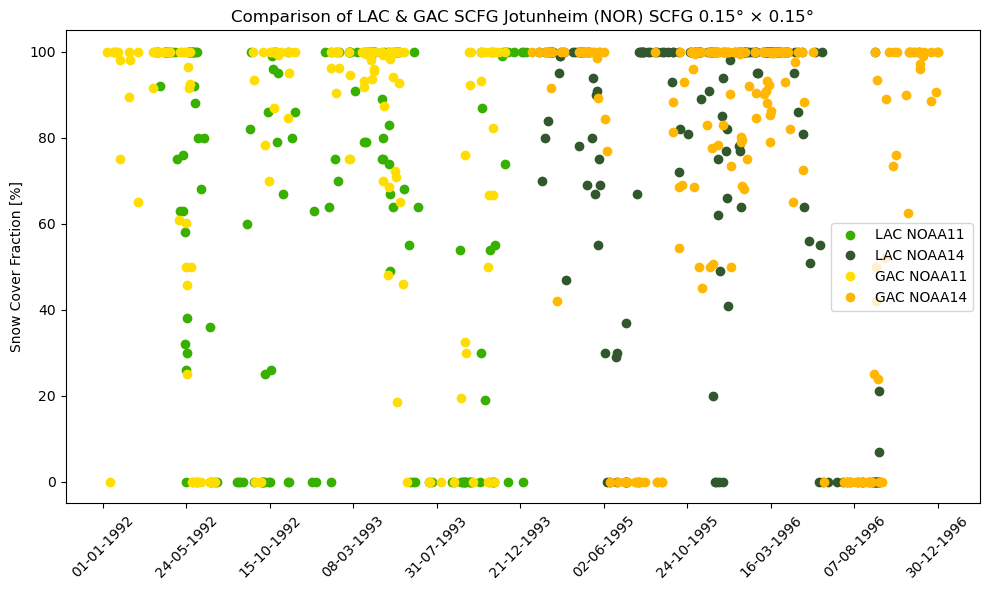

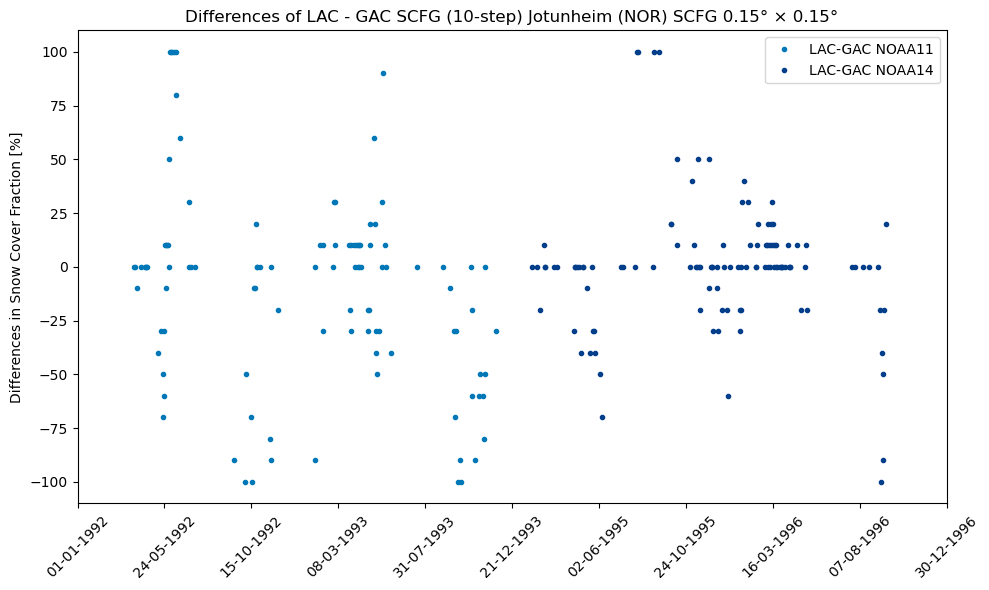


Top 10 NOAA11 LAC-GAC differences for Jotunheim (NOR):
02-06-1992: 100.0
04-06-1992: 100.0
05-06-1992: 100.0
09-06-1992: 100.0
12-06-1992: 100.0
04-10-1992: -100.0
16-10-1992: -100.0
23-09-1993: -100.0
27-09-1993: -100.0
17-09-1992: -90.0

Top 10 NOAA14 LAC-GAC differences for Jotunheim (NOR):
04-08-1995: 100.0
05-08-1995: 100.0
01-09-1995: 100.0
10-09-1995: 100.0
12-09-1996: -100.0
15-09-1996: -90.0
07-06-1995: -70.0
02-01-1996: -60.0
04-06-1995: -50.0
10-10-1995: 50.0


In [44]:
# Plot
if fullrange_comparison:
    plot_comparison(var_dict = new_dict, csv_path = csv_path, plot_category = plot_category, date_range=date_range)
else:
    plot_comparison(var_dict = filtered_data, csv_path = csv_path, plot_category = plot_category, date_range=date_range)

    # Plot
if fullrange_differences:
    plot_difference(var_dict = new_dict, csv_path = csv_path, date_range=date_range)
else:
    plot_difference(var_dict = filtered_data, csv_path = csv_path, date_range=date_range)